Use decision tree regression to predict the amount of concrete released from a demolition site.

Credit for providing a template for this notebook goes to Sujan Dutta, and the [ML_from_Scratch](https://github.com/Suji04/ML_from_Scratch) repository.

## Imports

In [49]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

## Data

In [50]:
full_data = pd.read_csv("./data/vattuniemi.csv")
display(full_data)
generated_data = pd.read_csv("./data/generated_data.csv")
# Pick features and labels
data = generated_data[["Area", "Storeys", "Concrete"]]
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values.reshape(-1, 1)
# Test-train split
X_tr, X_tst, y_tr, y_tst = train_test_split(X, y, test_size=0.2, random_state=41)

,Address,Type,Year,Area,Volume,Load_bearing_material,Facade_material,Storeys,Elevator,Sewer,Water_pipes,Concrete,Mineral_wool,Metal,Glass
0,heikkilantie 2,office,1988,9590,32400,concrete,brick,6,1,1,1,9028.1,20.5,214,25.1
1,heikkilantie 7,office,1988,15918,53570,steel,other,5,1,1,1,16000.0,37.5,967,20.0
2,heikkilantie 8,office,1966,2156,6689,concrete,concrete,3,0,1,1,2400.0,8.5,72,12.0
3,heikkilantie 10,office,1972,2135,6461,concrete,unknown,3,0,1,1,2800.0,9.0,84,14.0
4,italahdenkatu 15-17,office,1992,12300,42450,concrete,other,5,1,1,1,15950.0,100.0,663,100.0
5,italahdenkatu 18a,office,1991,12287,53168,concrete,concrete,6,1,1,1,14830.0,50.0,608,60.0
6,italahdenkatu 19,office,1978,12472,40128,concrete,unknown,5,1,1,1,20000.0,50.0,1000,10.0
7,italahdenkatu 20,other industrial,1965,3512,10650,concrete,unknown,3,1,1,1,8740.0,56.0,352,25.0
8,italahdenkatu 22a,other industrial,1974,13843,51276,concrete,metal plate,4,1,1,1,27160.0,100.0,1100,48.0
9,italahdenkatu 22b,office,1974,9045,32544,concrete,unknown,3,1,1,1,15900.0,70.0,658,40.0


# Visualizations and other testing

In [51]:
offices = full_data.loc[full_data["Type"] == "office"]
storages = full_data.loc[full_data["Type"] == "storage"]
others = full_data.loc[full_data["Type"] == "other industrial"]

x_lin = offices[["Area", "Storeys"]]
y_lin = offices[["Mineral_wool"]]

model = LinearRegression().fit(x_lin, y_lin)
#coef = model.coef_.item()
#intercept = model.intercept_.item()
print(model.score(x_lin, y_lin))

# fig, ax = plt.subplots(figsize=(12, 6))
# ax.plot(x_lin, y_lin, 'o')
# ax.plot(x_lin, coef*x_lin + intercept)

# plt.show()


0.3059624497534591


## Node class

In [52]:
class Node():
  def __init__(self, feature_index=None, threshold=None, left=None, right=None, var_red=None, value=None):
    ''' constructor '''

    # for decision node
    self.feature_index = feature_index
    self.threshold = threshold
    self.left = left
    self.right = right
    self.var_red = var_red

    # for leaf node
    self.value = value


## Tree class

In [53]:
class DecisionTreeRegressor():
  def __init__(self, min_samples_split=2, max_depth=2):
    ''' constructor '''

    # initialize the root of the tree
    self.root = None

    # stopping conditions
    self.min_samples_split = min_samples_split
    self.max_depth = max_depth

  def build_tree(self, dataset, curr_depth=0):
    ''' recursive function to build the tree '''

    X, y = dataset[:, :-1], dataset[:, -1]
    num_samples, num_features = np.shape(X)
    best_split = {}
    # split until stopping conditions are met
    if num_samples >= self.min_samples_split and curr_depth <= self.max_depth:
      # find the best split
      best_split = self.get_best_split(dataset, num_samples, num_features)
      # check if information gain is positive
      if best_split["var_red"] > 0:
        # recur left
        left_subtree = self.build_tree(best_split["dataset_left"], curr_depth+1)
        # recur right
        right_subtree = self.build_tree(best_split["dataset_right"], curr_depth+1)
        # return decision node
        return Node(best_split["feature_index"], best_split["threshold"],
                    left_subtree, right_subtree, best_split["var_red"])

    # compute leaf node
    leaf_value = self.calculate_leaf_value(y)
    # return leaf node
    return Node(value=leaf_value)

  def get_best_split(self, dataset, num_samples, num_features):
    ''' function to find the best split '''

    # dictionary to store the best split
    best_split = {}
    max_var_red = -float("inf")
    # loop over all the features
    for feature_index in range(num_features):
      feature_values = dataset[:, feature_index]
      possible_thresholds = np.unique(feature_values)
      # loop over all the feature values present in the data
      for threshold in possible_thresholds:
        # get current split
        dataset_left, dataset_right = self.split(dataset, feature_index, threshold)
        # check if childs are not null
        if len(dataset_left) > 0 and len(dataset_right) > 0:
          y, left_y, right_y = dataset[:, -1], dataset_left[:, -1], dataset_right[:, -1]
          # compute information gain
          curr_var_red = self.variance_reduction(y, left_y, right_y)
          # update the best split if needed
          if curr_var_red > max_var_red:
            best_split["feature_index"] = feature_index
            best_split["threshold"] = threshold
            best_split["dataset_left"] = dataset_left
            best_split["dataset_right"] = dataset_right
            best_split["var_red"] = curr_var_red
            max_var_red = curr_var_red

    # return best split
    return best_split

  def split(self, dataset, feature_index, threshold):
    ''' function to split the data '''
    
    dataset_left = np.array([row for row in dataset if row[feature_index]<=threshold])
    dataset_right = np.array([row for row in dataset if row[feature_index]>threshold])
    return dataset_left, dataset_right
  
  def variance_reduction(self, parent, l_child, r_child):
    ''' function to compute variance reduction '''
    
    weight_l = len(l_child) / len(parent)
    weight_r = len(r_child) / len(parent)
    reduction = np.var(parent) - (weight_l * np.var(l_child) + weight_r * np.var(r_child))
    return reduction
  
  def calculate_leaf_value(self, y):
    ''' function to compute leaf node '''
    
    val = np.mean(y)
    return val

  def print_tree(self, tree=None, indent=" "):
    ''' function to print the tree '''

    if not tree:
      tree = self.root

    if tree.value is not None:
      print(tree.value)

    else:
      print("X_"+str(tree.feature_index), "<=", tree.threshold, "?", tree.var_red)
      print("%sleft:" % (indent), end="")
      self.print_tree(tree.left, indent + indent)
      print("%sright:" % (indent), end="")
      self.print_tree(tree.right, indent + indent)

  def fit(self, X, y):
    ''' function to train the tree '''
    
    dataset = np.concatenate((X, y), axis=1)
    self.root = self.build_tree(dataset)
      
  def make_prediction(self, x, tree):
    ''' function to predict new dataset '''
    
    if tree.value!=None: return tree.value
    feature_val = x[tree.feature_index]
    if feature_val<=tree.threshold:
      return self.make_prediction(x, tree.left)
    else:
      return self.make_prediction(x, tree.right)
  
  def predict(self, X):
    ''' function to predict a single data point '''
    
    predictions = [self.make_prediction(x, self.root) for x in X]
    return predictions


## Fit the model

In [54]:
regressor = DecisionTreeRegressor(min_samples_split=2, max_depth=3)
regressor.fit(X_tr, y_tr)
regressor.print_tree()

X_0 <= 12741.770863504882 ? 11926456.029601596
 left:X_0 <= 9196.471106644678 ? 3642832.688118022
  left:X_0 <= 5480.768750040205 ? 1250712.7165976493
    left:4579.7948196636735
    right:X_0 <= 5759.223099554321 ? 159146.51668410748
        left:8548.073002927305
        right:9847.98128615079
  right:X_0 <= 11544.345169940943 ? 767564.6194406357
    left:X_0 <= 10076.84544212126 ? 468122.1858118344
        left:12640.443048302062
        right:11189.047224912298
    right:X_0 <= 12114.260751534166 ? 1102049.186972998
        left:14491.21727928336
        right:11866.75401633201
 right:X_0 <= 14912.652261564914 ? 1452990.7387274913
  left:X_0 <= 14864.34390875784 ? 2936467.280737894
    left:X_0 <= 14460.200704265371 ? 2707640.704543149
        left:16875.11222720505
        right:21290.427965938878
    right:X_0 <= 14883.502275796236 ? 1401085.6648413774
        left:13138.893079846348
        right:15649.846184105008
  right:X_0 <= 15032.04440202876 ? 1495563.9476111475
    left:2

## Test the model

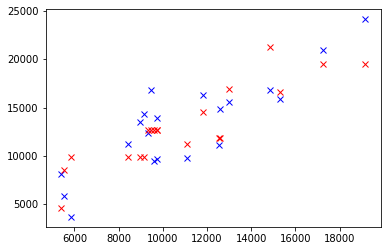

In [55]:
y_pred = regressor.predict(X_tst)
np.sqrt(mean_squared_error(y_tst, y_pred))
fig = plt.figure()
plt.plot(X_tst[:, 0], y_tst, 'bx')
plt.plot(X_tst[:, 0], y_pred, 'rx')
plt.show()
